# MolCrysKit Ideal Polyhedra Gallery

This notebook visualizes the ideal coordination polyhedra registered in `molcrys_kit.structures.polyhedra` for CN=4 through CN=12. Vertices are plotted as black dots, convex-hull faces as translucent triangles, and hull edges as solid lines. The coordinates are unit-sphere-normalized angular reference geometries for shape scoring, not crystal-scale distances.

In [1]:
%matplotlib inline

import math
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
from scipy.spatial import ConvexHull, QhullError

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from molcrys_kit.structures.polyhedra import (  # noqa: E402
    get_polyhedron,
    ideal_polyhedra_for_cn,
    list_polyhedra,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 10,
})

In [2]:
def _all_pair_edges(n_points):
    """Fallback edge list for inputs that cannot form a 2-D or 3-D hull."""
    return [tuple(edge) for edge in combinations(range(n_points), 2)]


def _coplanar_edges(vertices, *, tol=1e-10):
    """Return outline edges for coplanar points by projecting them to 2-D."""
    if len(vertices) < 4:
        return _all_pair_edges(len(vertices))

    centered = vertices - vertices.mean(axis=0)
    _, singular_values, vh = np.linalg.svd(centered, full_matrices=False)
    rank = int(np.sum(singular_values > tol))
    if rank < 2:
        return _all_pair_edges(len(vertices))

    basis = vh[:2].T
    projected = centered @ basis
    try:
        hull_2d = ConvexHull(projected)
    except QhullError:
        return _all_pair_edges(len(vertices))

    outline = list(hull_2d.vertices)
    return sorted(
        tuple(sorted((int(outline[i]), int(outline[(i + 1) % len(outline)]))))
        for i in range(len(outline))
    )


def _hull_geometry(vertices):
    """Return hull triangles and edge-index pairs for a set of vertices."""
    vertices = np.asarray(vertices, dtype=float)
    if len(vertices) < 4:
        return [], _all_pair_edges(len(vertices))

    try:
        hull = ConvexHull(vertices)
    except QhullError:
        return [], _coplanar_edges(vertices)

    triangles = [vertices[simplex] for simplex in hull.simplices]
    edges = set()
    for simplex in hull.simplices:
        for i, j in combinations(simplex, 2):
            edges.add(tuple(sorted((int(i), int(j)))))
    return triangles, sorted(edges)

In [3]:
def _set_clean_3d_axes(ax, *, limit=1.15):
    """Use fixed limits so every reference shape appears at the same scale."""
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_alpha(0.0)
        axis._axinfo["grid"]["linewidth"] = 0.0


def _draw_unit_sphere(ax, *, radius=1.0):
    """Draw a faint unit-sphere wireframe for close-up reference plots."""
    theta = np.linspace(0.0, 2.0 * math.pi, 48)
    phi = np.linspace(0.0, math.pi, 24)
    x = radius * np.outer(np.cos(theta), np.sin(phi))
    y = radius * np.outer(np.sin(theta), np.sin(phi))
    z = radius * np.outer(np.ones_like(theta), np.cos(phi))
    ax.plot_wireframe(x, y, z, color="0.8", linewidth=0.3, alpha=0.25)


def plot_polyhedron(ax, poly, *, show_sphere=False):
    """Plot one IdealPolyhedron on a 3-D matplotlib axes."""
    vertices = np.asarray(poly.vertices, dtype=float)
    triangles, edges = _hull_geometry(vertices)

    if triangles:
        faces = Poly3DCollection(
            triangles,
            facecolors="#4C78A8",
            edgecolors="none",
            linewidths=0.0,
            alpha=0.18,
        )
        ax.add_collection3d(faces)

    if edges:
        segments = [(vertices[i], vertices[j]) for i, j in edges]
        ax.add_collection3d(
            Line3DCollection(segments, colors="#2F4B7C", linewidths=1.3, alpha=0.9)
        )

    ax.scatter(
        vertices[:, 0],
        vertices[:, 1],
        vertices[:, 2],
        s=24,
        c="black",
        depthshade=True,
    )

    if show_sphere:
        _draw_unit_sphere(ax)

    ax.set_title(f"{poly.name}\nCN={poly.cn}, {poly.point_group}, {poly.category}")
    ax.view_init(elev=22, azim=38)
    _set_clean_3d_axes(ax)

## Full Gallery

The gallery below is generated directly from `list_polyhedra()`, so new registry entries appear automatically the next time the notebook is run.

Rendered 20 registered polyhedra.


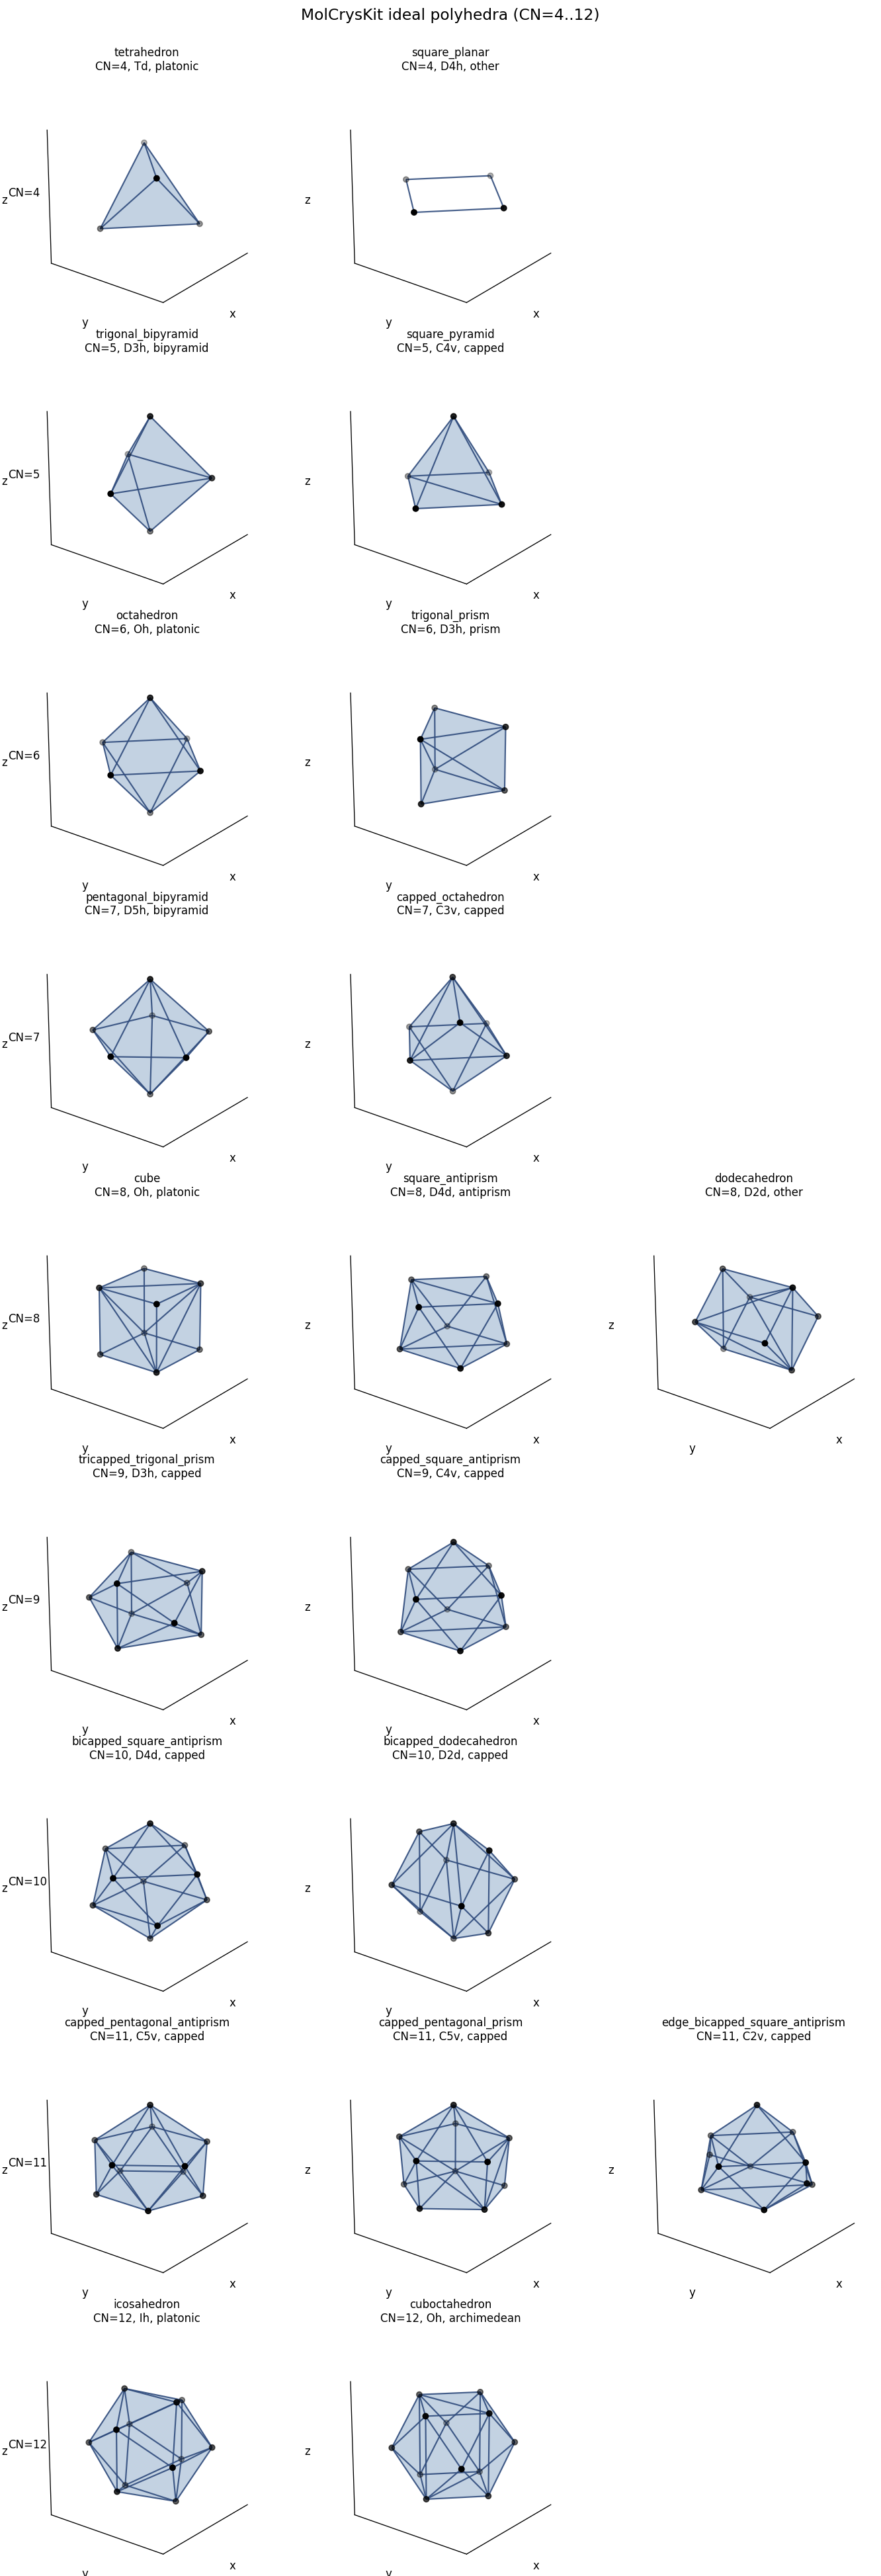

In [4]:
polys = list_polyhedra()
by_cn = {
    cn: [poly for poly in polys if poly.cn == cn]
    for cn in sorted({poly.cn for poly in polys})
}

ncols = max(len(items) for items in by_cn.values())
nrows = len(by_cn)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.0 * ncols, 3.6 * nrows),
    subplot_kw={"projection": "3d"},
    squeeze=False,
)

for r, (cn, items) in enumerate(by_cn.items()):
    for c in range(ncols):
        ax = axes[r, c]
        if c < len(items):
            plot_polyhedron(ax, items[c])
        else:
            ax.set_axis_off()
    axes[r, 0].text2D(-0.08, 0.5, f"CN={cn}", transform=axes[r, 0].transAxes)

fig.suptitle("MolCrysKit ideal polyhedra (CN=4..12)", y=1.0, fontsize=14)
plt.tight_layout()
print(f"Rendered {sum(len(items) for items in by_cn.values())} registered polyhedra.")

## Single-Polyhedron Close-Up

Change the `name` variable to any registered polyhedron name to inspect it with a faint unit-sphere wireframe.

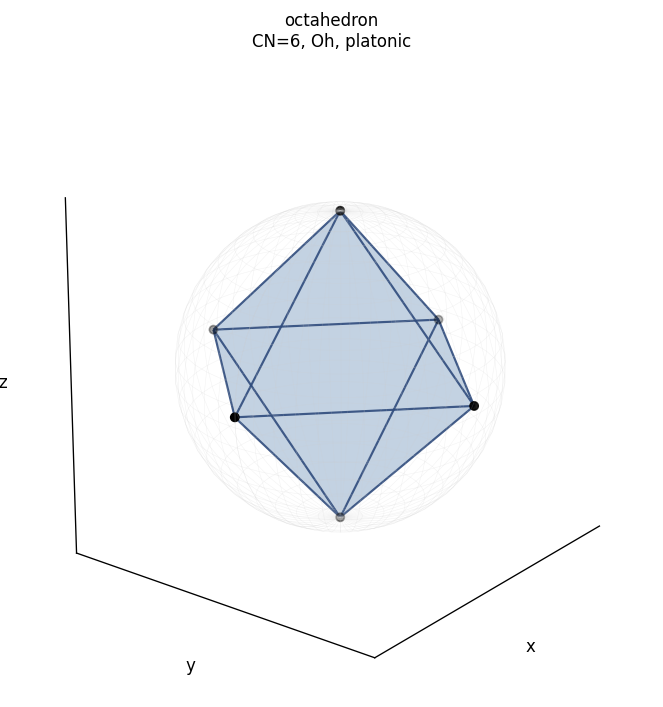

In [5]:
name = "octahedron"
poly = get_polyhedron(name)
if poly is None:
    raise ValueError(f"Unknown polyhedron: {name}")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
plot_polyhedron(ax, poly, show_sphere=True)
plt.tight_layout()

## Same-CN Comparison

CN=8 has three registered candidates. Viewing them side by side gives an intuitive feel for what the angular-RMSD comparison in `packing_shell.angular_rmsd_vs_ideals` distinguishes.

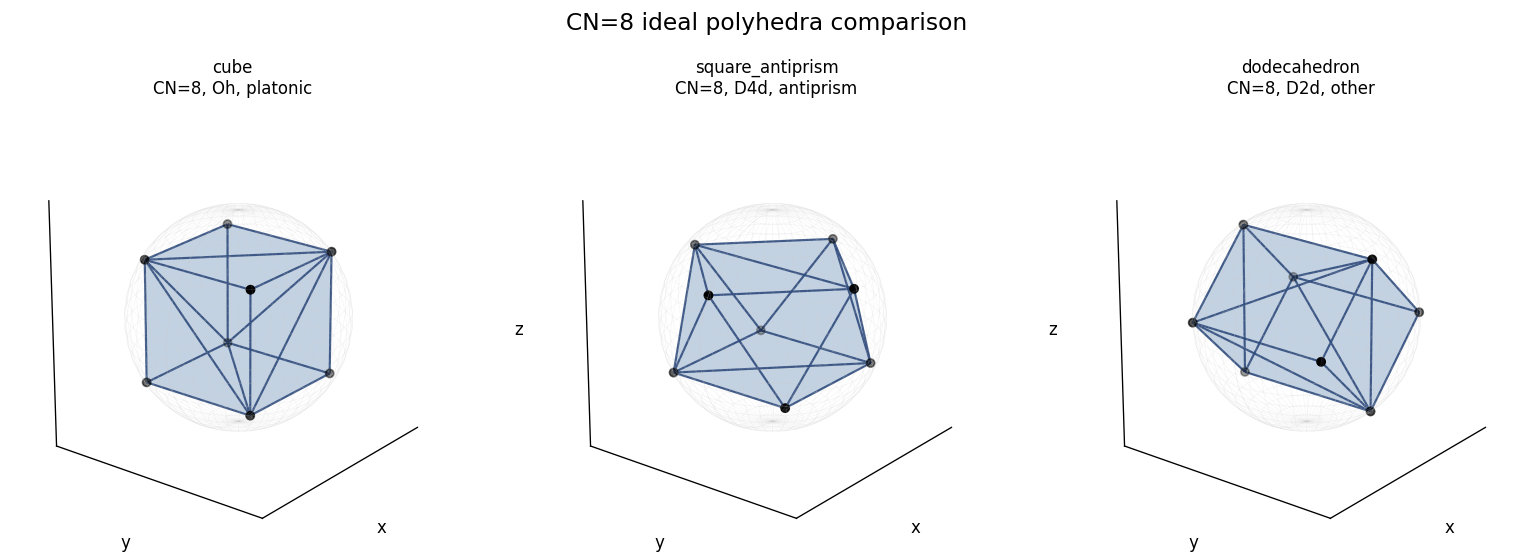

In [6]:
cn8_names = ("cube", "square_antiprism", "dodecahedron")
cn8_polys = [get_polyhedron(name) for name in cn8_names]
if any(poly is None for poly in cn8_polys):
    missing = [name for name, poly in zip(cn8_names, cn8_polys) if poly is None]
    raise ValueError(f"Missing CN=8 polyhedra: {missing}")

fig, axes = plt.subplots(
    1,
    len(cn8_polys),
    figsize=(4.5 * len(cn8_polys), 4.5),
    subplot_kw={"projection": "3d"},
)
for ax, poly in zip(axes, cn8_polys):
    plot_polyhedron(ax, poly, show_sphere=True)

fig.suptitle("CN=8 ideal polyhedra comparison", y=1.02, fontsize=14)
plt.tight_layout()

## Notes

- To add a new shape to this gallery, register it in `molcrys_kit.structures.polyhedra`; because the full gallery is driven by `list_polyhedra()`, the notebook picks it up automatically.
- These plots are the same normalized angular reference geometries used by `molcrys_kit.analysis.packing_shell.angular_rmsd_vs_ideals`, so they show what the scoring function compares rather than physical crystal-scale coordinates.
- Capped and other asymmetric references may have centroids that are not exactly at the origin; every subplot uses fixed unit-sphere limits so visual scale stays comparable.